In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']
benchmark = '^NSEI'

data = yf.download(
    stocks + [benchmark],
    start='2019-01-01',
    auto_adjust=True
)['Close']
data.dropna(inplace=True)


[*********************100%***********************]  4 of 4 completed


In [2]:
returns = data.pct_change().dropna()

In [3]:
risk_free_rate = 0.05
trading_days = 252

annual_return = returns.mean() * trading_days
volatility = returns.std() * np.sqrt(trading_days)
sharpe_ratio = (annual_return - risk_free_rate) / volatility

cumulative_returns = (1 + returns).cumprod()
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_drawdown = drawdown.min()

summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Volatility': volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
})

summary

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Ticker,,,,
INFY.NS,0.192814,0.274685,0.519919,-0.365498
RELIANCE.NS,0.202589,0.281441,0.542172,-0.450884
TCS.NS,0.128840,0.236300,0.333645,-0.344490
^NSEI,0.144645,0.175503,0.539277,-0.384399


In [4]:
benchmark_metrics = summary.loc[benchmark]
stock_metrics = summary.drop(index=benchmark)

stock_metrics

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Ticker,,,,
INFY.NS,0.192814,0.274685,0.519919,-0.365498
RELIANCE.NS,0.202589,0.281441,0.542172,-0.450884
TCS.NS,0.128840,0.236300,0.333645,-0.344490


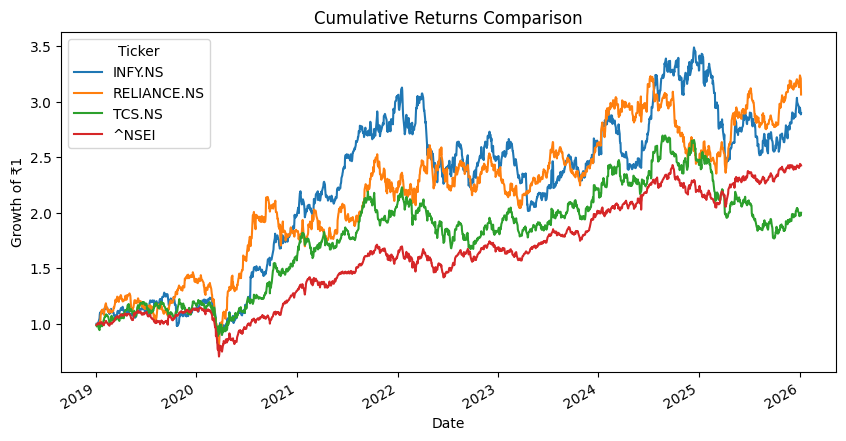

In [5]:
cumulative_returns.plot(figsize=(10,5))
plt.title('Cumulative Returns Comparison')
plt.ylabel('Growth of ₹1')
plt.show()

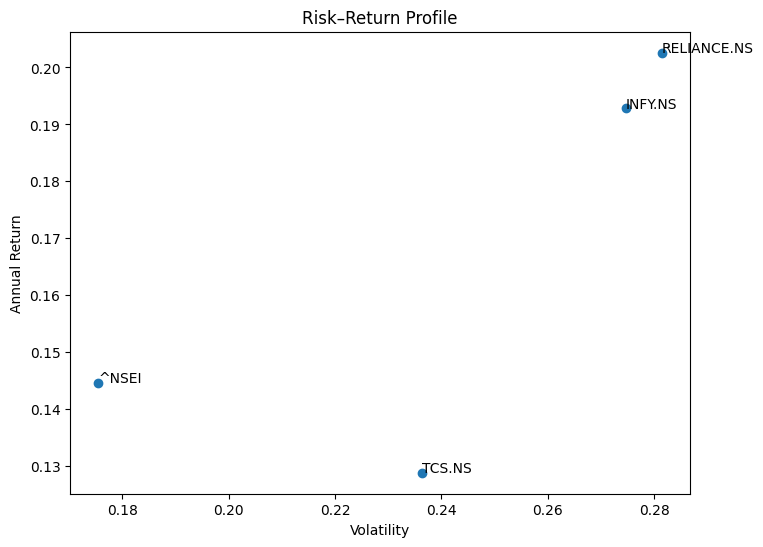

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(volatility, annual_return)

for i in annual_return.index:
    plt.annotate(i, (volatility[i], annual_return[i]))

plt.xlabel('Volatility')
plt.ylabel('Annual Return')
plt.title('Risk–Return Profile')
plt.show()


Among the selected equities, higher returns are generally associated
with higher volatility, indicating a clear risk–return tradeoff.
Certain stocks deliver moderate returns with comparatively lower risk,
making them more suitable for risk-adjusted investment strategies.


Sharpe ratio analysis indicates that some equities outperform the
market benchmark on a risk-adjusted basis, suggesting superior return
generation per unit of risk compared to the broader index.


Maximum drawdown highlights downside risk during market stress.
Stocks with lower drawdowns demonstrate stronger capital preservation
characteristics relative to both peers and the benchmark.


While the benchmark offers diversified exposure, select individual
equities exhibit better risk-adjusted performance, supporting the case
for active stock selection under disciplined risk management.
